**Import necessary libraries**

In [1]:
import pandas as pd
import random

**Parameters and Symptom distribution**

In [18]:
TOTAL_ROWS = 70000
UNKNOWN_PERCENT = 0.05

SYMPTOM_COUNT_DISTRIBUTION = {
    3: 0.55,
    4: 0.35,
    5: 0.10
}

**Load the datasets**

In [6]:
symptom_df = pd.read_csv(r"C:\Users\chips\Desktop\HygionX Model Files\Datasets\Symptom_severity_dataset.csv")
disease_df = pd.read_csv(r"C:\Users\chips\Desktop\HygionX Model Files\Datasets\Disease_symptom_map_dataset.csv")
symptom_df.head()

,symptom,weight,red_flag
0,fever,3,no
1,chills,2,no
2,fatigue,3,no
3,weakness,3,no
4,weight loss,3,no


**Extract symptom information**

In [7]:
symptom_list = symptom_df["symptom"].tolist()
symptom_weights = dict(zip(symptom_df["symptom"], symptom_df["weight"]))
red_flags = dict(zip(symptom_df["symptom"], symptom_df["red_flag"]))

print("Total symptoms:", len(symptom_list))

Total symptoms: 343


In [8]:
def normalize_symptoms(symptoms):

    symptoms = [s.lower().strip() for s in symptoms]
    symptoms = list(set(symptoms))
    symptoms.sort()

    return symptoms

**Building Disease -> Symptom Map**

In [10]:
disease_symptoms = {}
for _, row in disease_df.iterrows():
    disease = row["disease"]
    symptoms = row["symptoms"].split(";")
    disease_symptoms[disease] = [s.strip() for s in symptoms]

disease_names = list(disease_symptoms.keys())

print("Total diseases:", len(disease_names))

Total diseases: 101


In [11]:
disease_list = list(disease_symptoms.keys())

samples_per_disease = TOTAL_ROWS // len(disease_list)

balanced_disease_pool = []

for disease in disease_list:
    balanced_disease_pool.extend([disease] * samples_per_disease)

random.shuffle(balanced_disease_pool)

**Triage Function**

In [12]:
def triage_from_score(score, red_flag_count):
    if red_flag_count >= 2:
        return "emergency"
    if score >= 15:
        return "emergency"
    elif score >= 10:
        return "urgent"
    elif score >= 6:
        return "moderate"
    else:
        return "low"

**Symptom count sampling**

In [13]:
def sample_symptom_count():
    r = random.random()
    cumulative = 0

    for count, prob in SYMPTOM_COUNT_DISTRIBUTION.items():
        cumulative += prob
        if r <= cumulative:
            return count

    return 3

**Dataset Generation**

In [19]:
rows = []

for disease in balanced_disease_pool:

    disease_symptom_list = disease_symptoms[disease]

    core_symptoms = disease_symptom_list[:3]
    optional_symptoms = disease_symptom_list[3:]

    symptom_target = sample_symptom_count()

    symptoms = []

    # 1–3 core symptoms
    symptom_target = sample_symptom_count()

    # get disease symptoms
    available_symptoms = disease_symptom_list.copy()

    # if disease has fewer symptoms than needed
    if len(available_symptoms) < symptom_target:
        symptoms = available_symptoms
    else:
        symptoms = random.sample(available_symptoms, symptom_target)

    symptoms = normalize_symptoms(symptoms)

    # enforce minimum symptoms
    if len(symptoms) < 3:
        additional = random.sample(disease_symptom_list, 3 - len(symptoms))
        symptoms.extend(additional)
        symptoms = normalize_symptoms(symptoms)

    # enforce symptom target size
    if len(symptoms) > symptom_target:
        symptoms = random.sample(symptoms, symptom_target)

    symptom_count = len(symptoms)

    severity_score = sum(symptom_weights.get(s, 1) for s in symptoms)

    red_flag_count = sum(1 for s in symptoms if red_flags.get(s, "no") == "yes")

    triage = triage_from_score(severity_score, red_flag_count)

    rows.append({
        "symptoms": ";".join(symptoms),
        "symptom_count": symptom_count,
        "severity_score": severity_score,
        "red_flag_count": red_flag_count,
        "triage": triage,
        "disease": disease
    })

**Convert to DataFrame**

In [20]:
df = pd.DataFrame(rows)

print("Dataset generated successfully.")
print("Rows:", len(df))
df.head()

Dataset generated successfully.
Rows: 69993


,symptoms,symptom_count,severity_score,red_flag_count,triage,disease
0,infertility;irregular menstruation;weight gain,3,5,0,low,Polycystic Ovary Syndrome
1,confusion;focal weakness;loss of sensation;slu...,4,19,4,emergency,Stroke
2,abdominal pain;diarrhea;weight loss,3,7,0,moderate,Crohns Disease
3,fatigue;fever;loss of smell;loss of taste,4,8,0,moderate,COVID-19
4,fatigue;leg swelling;rapid heartbeat;shortness...,4,13,1,urgent,Heart Failure


**Save the Dataset**

In [21]:
df.to_csv(r"C:\Users\chips\Desktop\HygionX Model Files\Datasets\Sythetic Dataset Generation mar 14.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


In [15]:
import pandas as pd

df = pd.read_csv("/content/synthetic_patient_dataset.csv")

print(df["disease"].value_counts())

disease
unknown                    2505
Tuberculosis                530
Hypothermia                 524
COVID-19                    515
Sepsis                      513
                           ... 
Cellulitis                  429
Crohns Disease              426
Urinary Tract Infection     420
Coronary Heart Disease      412
Hypotension                 410
Name: count, Length: 102, dtype: int64


In [16]:
df["symptom_count"].value_counts(normalize=True)

,proportion
symptom_count,
4,0.32304
3,0.29136
5,0.19228
2,0.13582
6,0.04304
7,0.00696
1,0.00490
8,0.00260


In [17]:
df["triage"].value_counts()

,count
triage,
moderate,18947
urgent,14587
low,9952
emergency,6514


In [18]:
df["symptoms"].nunique()

32891


### Distribution of Severity Score

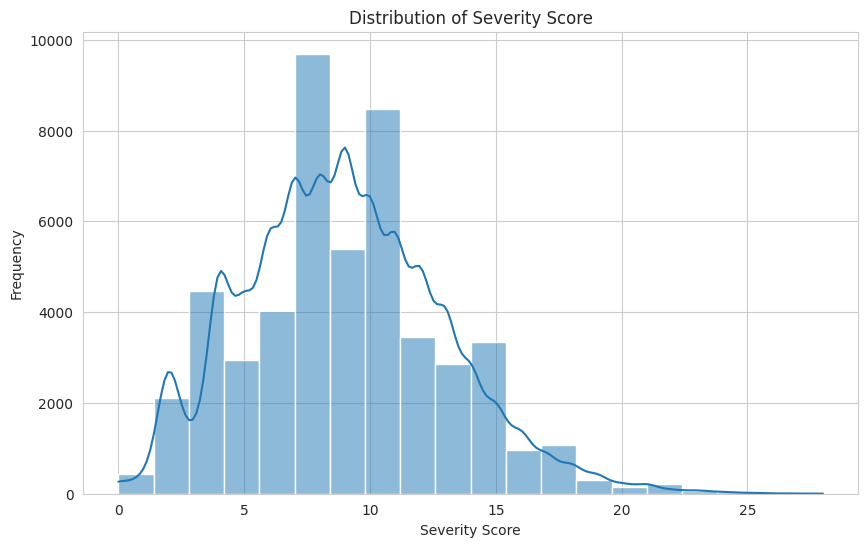

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df['severity_score'], bins=20, kde=True)
plt.title('Distribution of Severity Score')
plt.xlabel('Severity Score')
plt.ylabel('Frequency')
plt.show()

### Distribution of Triage Levels

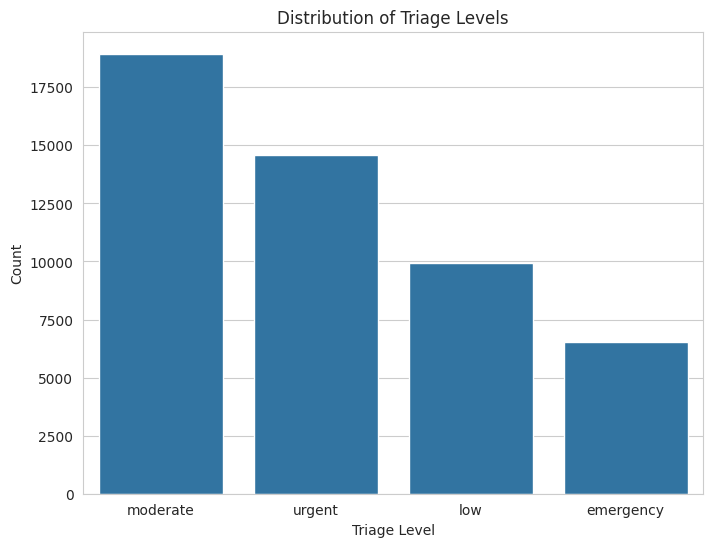

In [21]:
plt.figure(figsize=(8, 6))
sns.countplot(x='triage', data=df, order=df['triage'].value_counts().index)
plt.title('Distribution of Triage Levels')
plt.xlabel('Triage Level')
plt.ylabel('Count')
plt.show()

### Relationship between Symptom Count and Severity Score

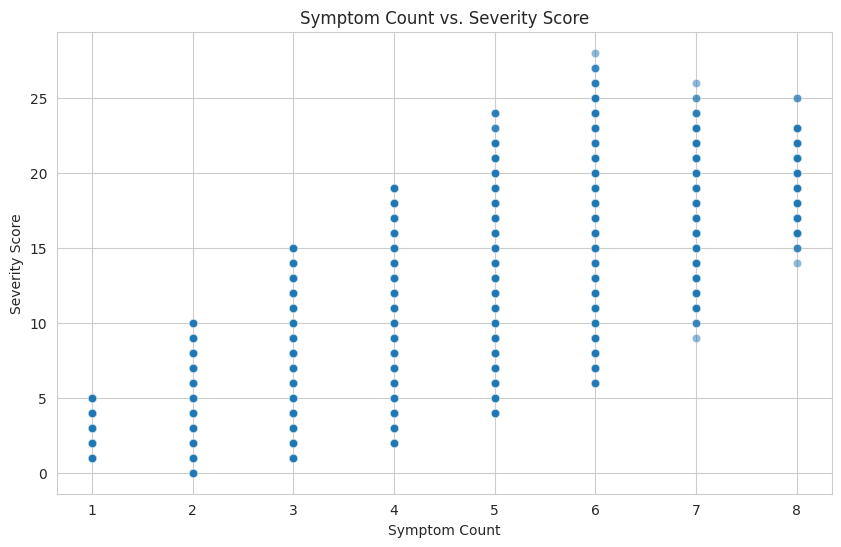

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='symptom_count', y='severity_score', data=df, alpha=0.5)
plt.title('Symptom Count vs. Severity Score')
plt.xlabel('Symptom Count')
plt.ylabel('Severity Score')
plt.show()

### Correlation Matrix of Numerical Features

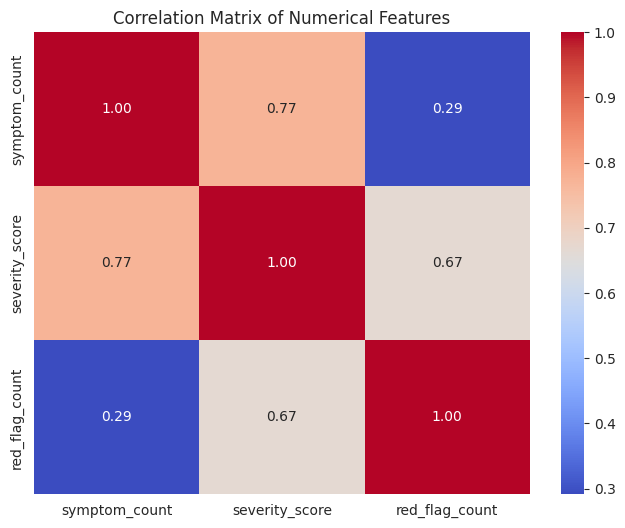

In [23]:
numerical_cols = ['symptom_count', 'severity_score', 'red_flag_count']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()